<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_6_matching_pursuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook Setup
-----------------------------------------

In [21]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
from scipy import fft

Set the random number generator seed for ensuring reproducibility of results 
across multiple executions

In [22]:
np.random.seed(42)

Initialize all the variables

In [23]:
M = 32     # signal dimension
N = 2 * M  # number of atoms in the expansion

# Matrix containing the standard basis (a Kronecker delta in each column)
C = np.zeros((M, M))
# Matrix containing the DCT basis (a DCT function in each column)
DCT = np.zeros((M, M))

Generate the 1D-DCT basis and the 1D standard basis

In [24]:
for i in range(M):
    C[i, i] = 1.0
    DCT[:, i] = fft.idct(C[:, i], norm='ortho')

Define the dictionary $D = [DCT, C]$

Text(0.5, 1.0, 'Our dictionary M = 32, N = 64')

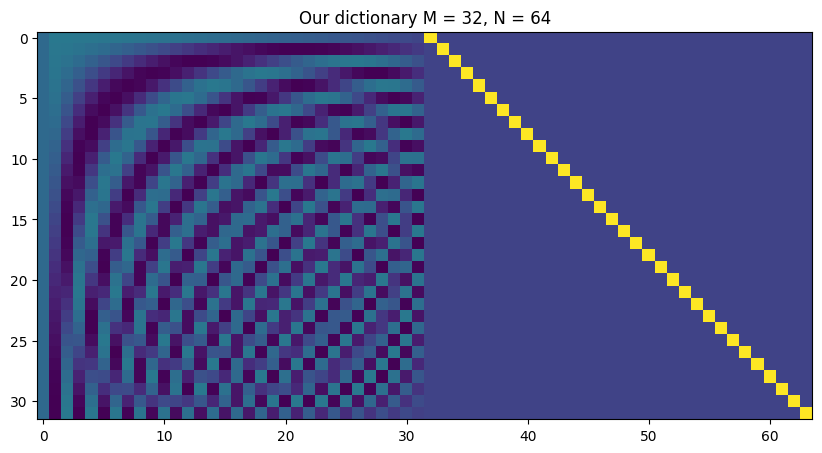

In [25]:
D = np.hstack((DCT, C))

plt.figure(figsize=(10, 10))
plt.imshow(D)
plt.title(f'Our dictionary M = {M}, N = {N}')

Generate a signal that is sparse w.r.t. $[DCT, C]$
-----------------------------------------
To this purpose add a spike to the sum of few DCT atoms, i.e. add a spike to 
$\mathbf{s}$ that is sparse w.r.t. $C$  
Bear in mind that the spike is to be considered a signal to be reconstructed, 
rather than noise

In [26]:
L = 5
sigma_noise = 0.2

Randomly define the coefficients of a sparse representation w.r.t. $DCT$

In [27]:
x0 = np.zeros(N)
idxs = np.random.choice(M, L, replace=False)
x0[idxs] = np.random.uniform(-1.0, 1.0, size=(L,))

Choose the spike location and update $x_0$  
We have decided to place the spike at a standard-basis component, as the spike 
is meant be sparse w.r.t. $C$

In [28]:
spikeLocation = M + np.random.randint(0, M)
l = np.random.uniform(1.0, 5.0)
x0[spikeLocation] = l * 1.0

Synthetize the corresponding signal in the signal domain and add noise


In [29]:
s0 = D @ x0
s = s0 + np.random.normal(0.0, sigma_noise, size=(M,))

Plot the sparse signal

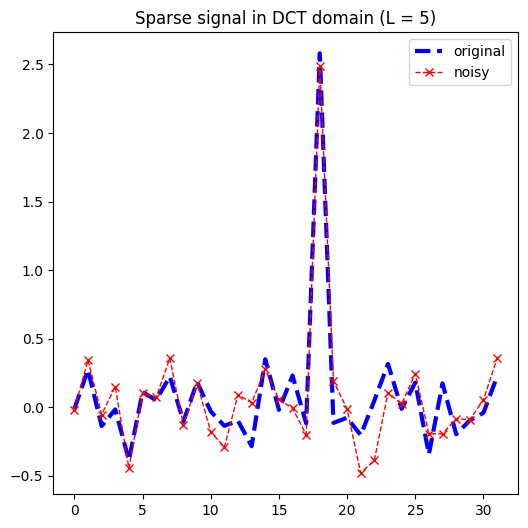

In [30]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6, 6))
plt.plot(s0, 'b--', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original', 'noisy'])

Matching Pursuit
----------------

Initialize all the variables, including the residual $r$, namely the components 
of the signal $s$ that cannot be represented by the coefficients   
At the beginning of the execution, $r = s$

In [31]:
x_MP = np.zeros(N)
r = s                           # Residual vector
l = 1                           # Iteration count
res_norm = np.linalg.norm(r)
MINIMUM_RES_NORM = 0.1

Continue the execution until one (or more) of the following conditions 
(or stopping criteria)
are met: 
- the sparsity of the representation reaches the sparsity level $L$
- the norm of the residual at the l-th iteration, namely `res_norm`, is above a 
certain minimum value
- the maxium number of iterations have been reached

During the sweep step, look for the column of $D$ that matches at best the 
residual $r$  
This corresponds to solving
$$
    e(j) = \min_{z_j}\|z_jd_j - r\|_2^2,
$$
which is obtained by setting
$$ 
    z_j = \frac{d_j^T \cdot r}{\|d_j\|_2^2} = d_j^T \cdot r \quad \forall j = 0,\dots, N - 1 
$$
since the columns of $D \text{ (}d_j\text{)}$ are already normalized  
Then find $d_j^{*}$, the column of D that matches at best $r$, or rather the
column labeled by the index $j^{*}$ such that
$$
j^{*} = \argmin_{j}e(j)
$$

During the update step, update the $j^{*}$ coefficient of the solution by summing 
the new component $z_j^{*}$
$$
z_j^{*} = \frac{d_j^{*T} \cdot r}{\|d_j^{*}\|_2^2} = d_j^{*T} \cdot r
$$
Finally, remove the signal we have represented so far by updating the residual $r$, 
and compute again its norm

In [32]:
while np.count_nonzero(x_MP) < L and res_norm > MINIMUM_RES_NORM and l < 2*L:

    # Sweep step
    e = np.zeros(N)
    for j in range(N):
        e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2
    jStar = np.argmin(e)

    # Update step
    z_jStar = np.dot(r, D[:, jStar])
    x_MP[jStar] += z_jStar              # update the solution
    r -= z_jStar * D[:, jStar]          # update the residual
    res_norm = np.linalg.norm(r)        # compute residual norm

    l += 1

Reconstruct the signal, by inverting the transformation

In [33]:
s_hat_MP = D @ x_MP

Those part of the signal that have not been modeled by $\hat s$, i.e. the 
projection on the subspace of the $L$ most involved coefficients, corresponds 
to the norm of the residual

In [34]:
res_norm_MP = np.linalg.norm(r)
res_norm_MP

np.float64(0.826513762846688)

Show the results

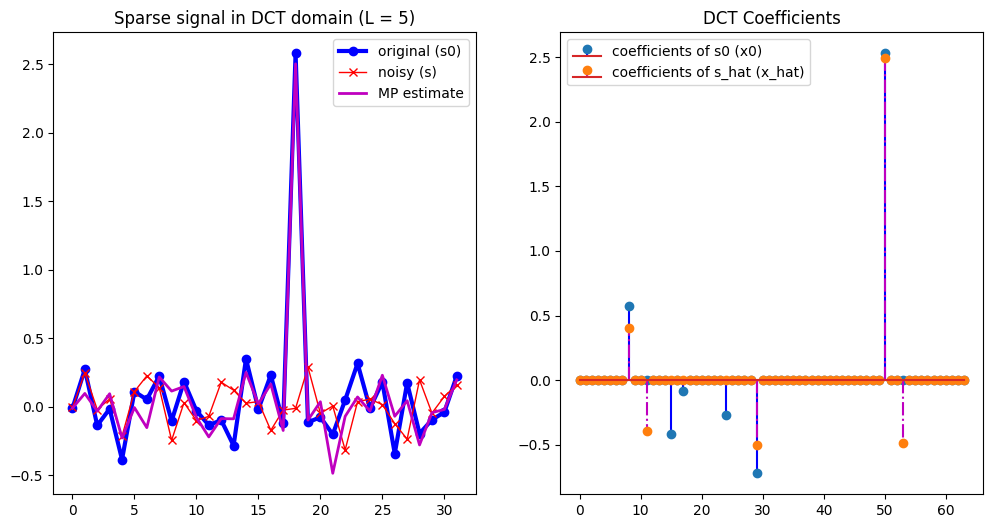

In [35]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_MP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal in DCT domain (L = {L:.0f})')
ax[0].legend(['original (s0)', 'noisy (s)', 'MP estimate'])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_MP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('DCT Coefficients')
ax[1].legend(['coefficients of s0 (x0)', 'coefficients of s_hat (x_hat)'])